# NILM Preprocessing — AMPds Event Extraction Approach

## Design decisions

| Decision | Detail |
|---|---|
| **50W hard threshold** | Any appliance reading below 50W → 0 (OFF). Eliminates sensor noise. |
| **P99 normalisation** | Computed from training split only. Caps at 99th percentile. |
| **Event extraction** | Extract each ON event with leading/trailing zeros. Not sliding windows. |
| **Fixed length patterns** | All patterns padded to `MAX_LEN` per appliance (longest event + context). |
| **Seq-to-Seq target** | Y is the full appliance sequence — not just a midpoint scalar. |
| **5-channel features** | Raw agg + autocorrelation + cross-correlation + sin/cos(hour). |
| **Chronological 70/10/20 split** | Events extracted from each split separately. |
| **Furnace dropped** | Signal indistinguishable from background at 60-second resolution. |

## What the doctor said
Keep leading and trailing zeros when extracting the appliance pattern. Extract multiple
patterns for the same appliance the same way (exact number of steps including leading
and trailing zeros). Extract the corresponding steps in the aggregate signal. Construct
your balanced dataset per appliance from these patterns.

## 0 · Imports

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
os.makedirs('nilm_datasets', exist_ok=True)
print('Imports OK')

Imports OK


## 1 · Load & Clean Data

In [97]:
ampd = pd.read_csv('Electricity_P.csv')

# Drop solar, unused columns, and Furnace
drop_cols = ['MHE', 'RSE', 'GRE', 'B1E', 'BME', 'EQE', 'OFE', 'UTE',
             'B2E', 'DNE', 'EBE', 'OUE', 'TVE', 'UNE', 'HTE', 'WOE','FRE']
ampd = ampd.drop(columns=[c for c in drop_cols if c in ampd.columns])

# Rename to human-readable
APPLIANCE_NAMES = {
    'CDE': 'Clothes Dryer',
    'CWE': 'Clothes Washer',
    'DWE': 'Dishwasher',
    'FGE': 'Kitchen Fridge',
    'HPE': 'Heat Pump',
    'WHE': 'Whole-House Meter',
}
ampd = ampd.rename(columns=APPLIANCE_NAMES)

MAINS_COL         = 'Whole-House Meter'
TARGET_APPLIANCES = [v for k, v in APPLIANCE_NAMES.items() if k != 'WHE']

# Convert timestamp
ampd = ampd.rename(columns={ampd.columns[0]: 'time'})
ampd['time'] = pd.to_datetime(ampd['time'], unit='s', errors='coerce')
ampd = ampd.set_index('time').sort_index()

# Clip negative values
for col in ampd.columns:
    ampd[col] = ampd[col].clip(lower=0)

print(f'Loaded: {len(ampd):,} rows')
print(f'Date range: {ampd.index[0].date()} to {ampd.index[-1].date()}')
print(f'Target appliances: {TARGET_APPLIANCES}')
ampd.head(3)

Loaded: 1,051,200 rows
Date range: 2012-04-01 to 2014-04-01
Target appliances: ['Clothes Dryer', 'Clothes Washer', 'Dishwasher', 'Kitchen Fridge', 'Heat Pump']


,Whole-House Meter,Clothes Washer,Dishwasher,Heat Pump,Clothes Dryer,Kitchen Fridge
time,,,,,,
2012-04-01 07:00:00,918,0,0,36,0,0
2012-04-01 07:01:00,913,0,0,37,0,0
2012-04-01 07:02:00,872,0,0,38,0,0


In [32]:
"""
app = 'Wall oven'
arr = ampd[app].values
is_on = (arr > 0).astype(int)
diff = np.diff(is_on, prepend=0)
starts = np.where(diff == 1)[0]
ends = np.where(diff == -1)[0]
if len(starts) > len(ends):
    ends = np.append(ends, len(arr)-1)

durations = ends - starts
print(f"Median event duration : {np.median(durations):.0f} min")
print(f"Mean event duration   : {np.mean(durations):.0f} min")
print(f"% events under 5 min  : {(durations < 5).mean()*100:.1f}%")
print(f"% events under 15 min : {(durations < 15).mean()*100:.1f}%")
print(f"% events over 30 min  : {(durations > 30).mean()*100:.1f}%")
Median event duration : 1 min
Mean event duration   : 2 min
% events under 5 min  : 99.5%
% events under 15 min : 99.5%
% events over 30 min  : 0.5%


THIS WHY WE DROPPED WALL OVEN  99.5% of events are under 5 minutes, so the model cant learn meaningful ON/OFF patternS
"""


'\napp = \'Wall oven\'\narr = ampd[app].values\nis_on = (arr > 0).astype(int)\ndiff = np.diff(is_on, prepend=0)\nstarts = np.where(diff == 1)[0]\nends = np.where(diff == -1)[0]\nif len(starts) > len(ends):\n    ends = np.append(ends, len(arr)-1)\n\ndurations = ends - starts\nprint(f"Median event duration : {np.median(durations):.0f} min")\nprint(f"Mean event duration   : {np.mean(durations):.0f} min")\nprint(f"% events under 5 min  : {(durations < 5).mean()*100:.1f}%")\nprint(f"% events under 15 min : {(durations < 15).mean()*100:.1f}%")\nprint(f"% events over 30 min  : {(durations > 30).mean()*100:.1f}%")\nMedian event duration : 1 min\nMean event duration   : 2 min\n% events under 5 min  : 99.5%\n% events under 15 min : 99.5%\n% events over 30 min  : 0.5%\n\n\nTHIS WHY WE DROPPED WALL OVEN  99.5% of events are under 5 minutes, so the model cant learn meaningful ON/OFF patternS\n'

## 2 · 50W Hard Threshold

Any appliance reading below 50W is set to 0 (treated as OFF).
Eliminates standby power and sensor noise from the real power signal.

In [98]:
WATTS_ON_THRESHOLD = 50.0

# Per-appliance threshold overrides.
# Clothes Washer sits at 100-200W during idle/tumble phases — 50W labels
# nearly everything as ON, giving the model no OFF signal to learn from.
APPLIANCE_ON_THRESHOLD = {
    'Clothes Washer': 50.0,   # filters low-power tumble/idle phases
}

for app in TARGET_APPLIANCES:
    if app not in ampd.columns:
        continue
    thr = APPLIANCE_ON_THRESHOLD.get(app, WATTS_ON_THRESHOLD)
    before = ampd[app].mean()
    n_before = (ampd[app] > 0).sum()
    ampd[app] = ampd[app].where(ampd[app] >= thr, other=0.0)
    after = ampd[app].mean()
    n_after = (ampd[app] > 0).sum()
    pct_zeroed = (1 - n_after / max(n_before, 1)) * 100
    print(f'{app:<20} thr={thr:.0f}W  {before:>8.1f} → {after:>8.1f}  {pct_zeroed:>6.1f}% zeroed')

print(f'\nDone. Values below {WATTS_ON_THRESHOLD}W set to 0.')

Clothes Dryer        thr=50W      53.1 →     53.0    14.1% zeroed
Clothes Washer       thr=50W       4.4 →      4.2    28.2% zeroed
Dishwasher           thr=50W      14.9 →     14.8    44.6% zeroed
Kitchen Fridge       thr=50W      50.4 →     49.8    25.9% zeroed
Heat Pump            thr=50W     168.3 →    135.0    92.6% zeroed

Done. Values below 50.0W set to 0.


## 3 · EDA

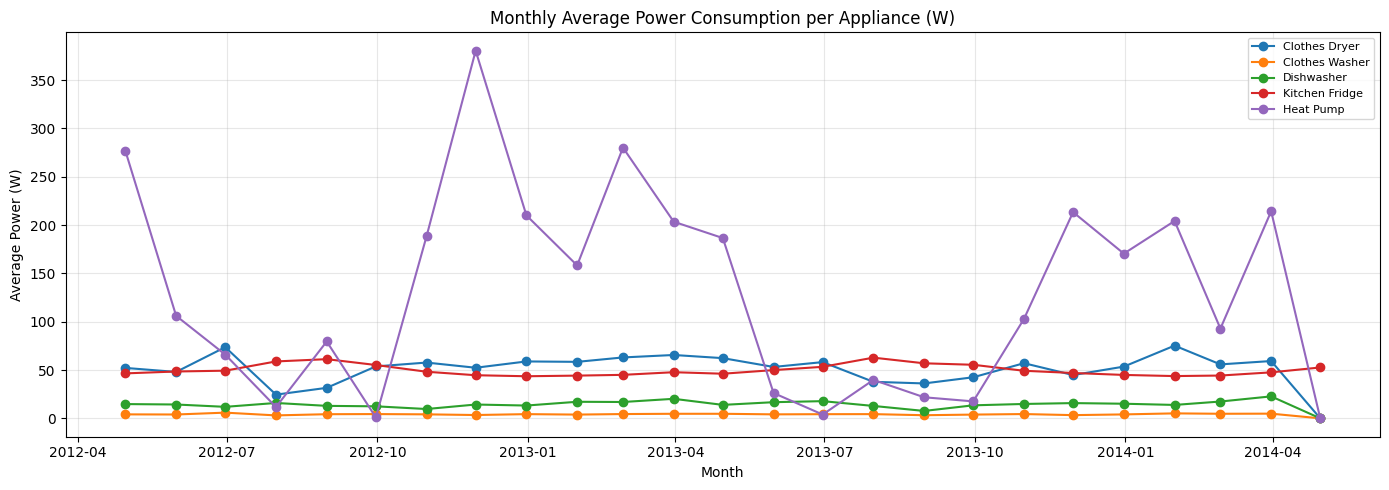

In [99]:
# Monthly average power per appliance
monthly = ampd[TARGET_APPLIANCES].resample('ME').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], marker='o', label=col)
ax.set_title('Monthly Average Power Consumption per Appliance (W)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Power (W)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [100]:
# ON% per appliance after threshold
print(f'{"Appliance":<20} {"Mean W":>8} {"Max W":>8} {"ON%":>8} {"Events est.":>12}')
print('-' * 60)
for app in TARGET_APPLIANCES:
    if app not in ampd.columns:
        continue
    s = ampd[app]
    is_on = s > 0
    # Estimate events: count ON->OFF transitions
    n_events = int((is_on.astype(int).diff() == 1).sum())
    print(f'{app:<20} {s.mean():>8.1f} {s.max():>8.0f} '
          f'{is_on.mean()*100:>7.1f}% {n_events:>12,}')

Appliance              Mean W    Max W      ON%  Events est.
------------------------------------------------------------
Clothes Dryer            53.0     5614     1.8%          471
Clothes Washer            4.2     1151     2.1%        4,362
Dishwasher               14.8      848     2.2%        2,036
Kitchen Fridge           49.8     1497    36.8%       30,307
Heat Pump               135.0     3701     7.4%        2,242


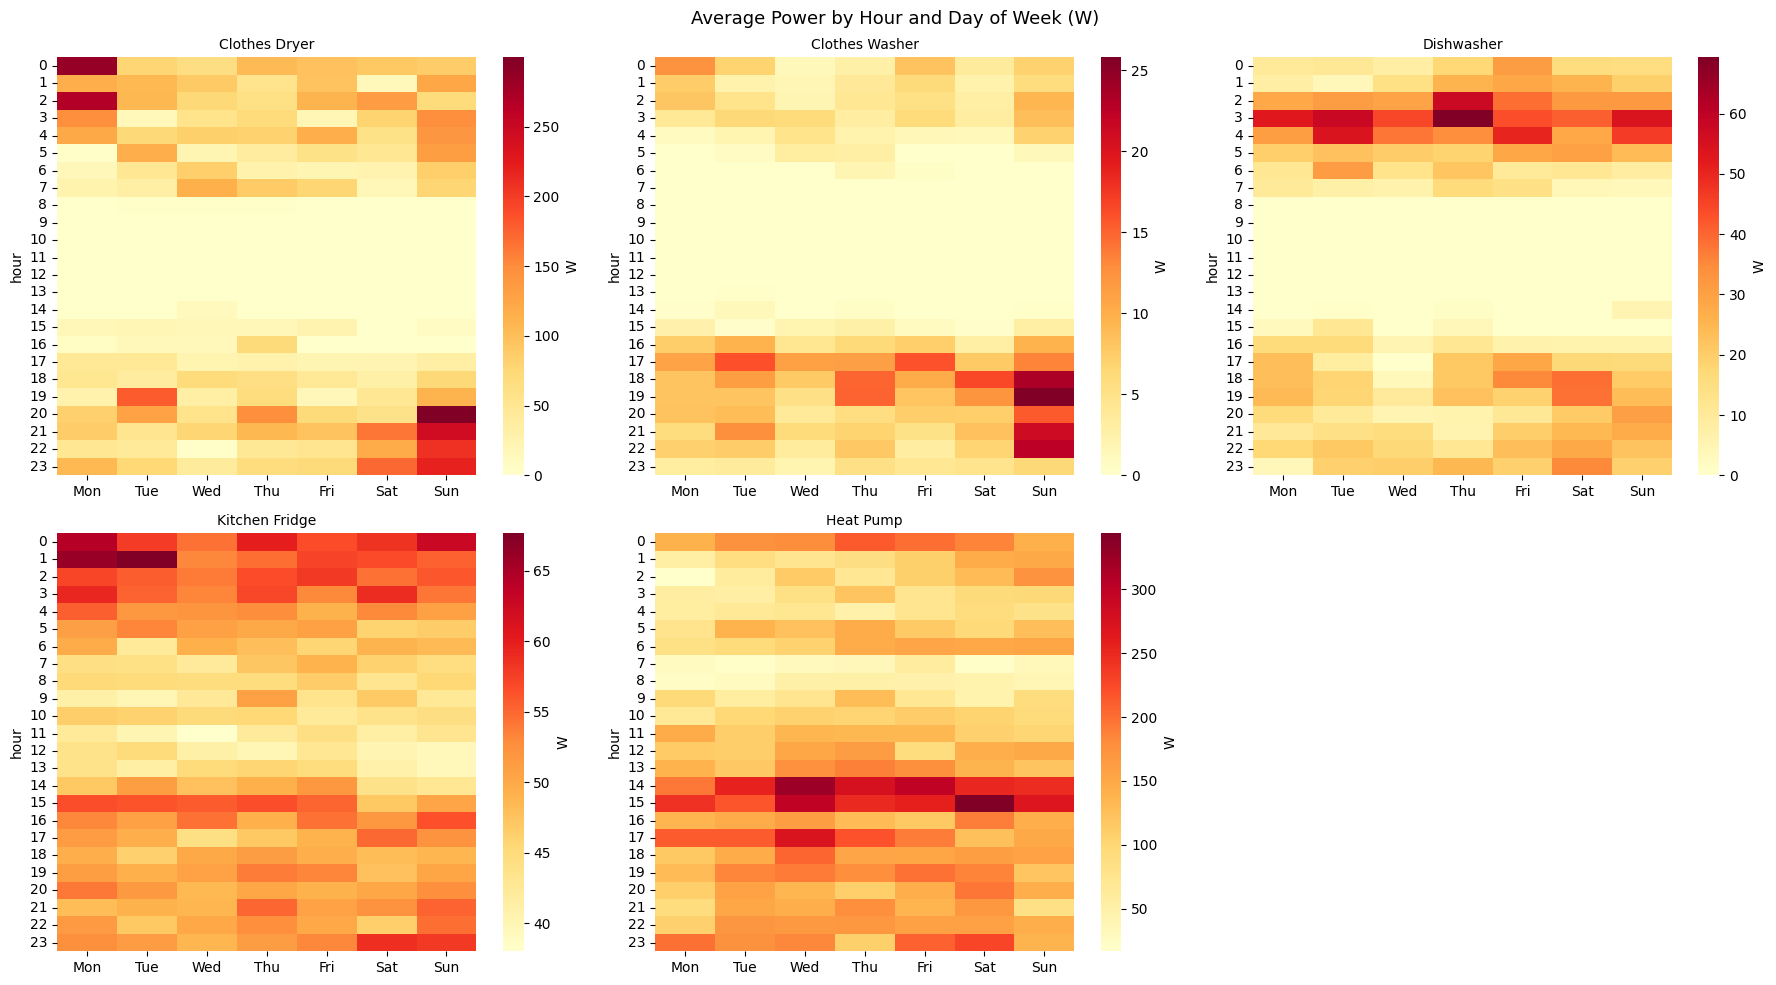

In [101]:
# Heatmap: hour x day-of-week per appliance
df_eda = ampd.copy()
df_eda['hour']      = df_eda.index.hour
df_eda['dayofweek'] = df_eda.index.dayofweek
day_labels          = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

n_apps = len(TARGET_APPLIANCES)
ncols  = 3
nrows  = (n_apps + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, TARGET_APPLIANCES):
    pivot = df_eda.pivot_table(values=col, index='hour',
                                columns='dayofweek', aggfunc='mean')
    pivot.columns = day_labels
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'W'})
    ax.set_title(col, fontsize=10)

for ax in axes[n_apps:]:
    ax.set_visible(False)

plt.suptitle('Average Power by Hour and Day of Week (W)', fontsize=13)
plt.tight_layout()
plt.show()

## 4 · Train / Val / Test Split (Chronological 70/10/20)

In [102]:
n         = len(ampd)
val_start = int(n * 0.80)
val_end   = int(n * 0.85)

df_train = ampd.iloc[:val_start].copy()
df_val   = ampd.iloc[val_start:val_end].copy()
df_test  = ampd.iloc[val_end:].copy()

print(f'Total : {n:,} rows')
print(f'Train : {len(df_train):,}  '
      f'{df_train.index[0].date()} to {df_train.index[-1].date()}')
print(f'Val   : {len(df_val):,}  '
      f'{df_val.index[0].date()} to {df_val.index[-1].date()}')
print(f'Test  : {len(df_test):,}  '
      f'{df_test.index[0].date()} to {df_test.index[-1].date()}')

Total : 1,051,200 rows
Train : 840,960  2012-04-01 to 2013-11-06
Val   : 52,560  2013-11-06 to 2013-12-12
Test  : 157,680  2013-12-12 to 2014-04-01


## 5 · P99 Normalisation

Caps computed from training split only to prevent data leakage.
P99 instead of max — prevents one spike from compressing all other readings.

In [103]:
def compute_norm_cap(series):
    """P99 cap computed from non-zero values."""
    arr     = series.clip(lower=0).values
    nonzero = arr[arr > 0]
    if len(nonzero) == 0:
        return 1.0
    return float(np.percentile(nonzero, 99))


def normalize_with_cap(arr, cap):
    """Normalise numpy array using precomputed cap. Clips to [0, 1]."""
    arr = np.clip(arr, 0, None).astype(np.float32)
    if cap <= 0:
        return arr
    return np.clip(arr / cap, 0.0, 1.0).astype(np.float32)


# Compute caps from training data only
norm_caps = {}
norm_caps[MAINS_COL] = compute_norm_cap(df_train[MAINS_COL])
for app in TARGET_APPLIANCES:
    if app in df_train.columns:
        norm_caps[app] = compute_norm_cap(df_train[app])

print(f'{"Column":<25} {"Cap (W)":>10}')
print('-' * 37)
for k, v in norm_caps.items():
    print(f'{k:<25} {v:>10.1f}')

# Save caps for use in pipeline notebook
pd.DataFrame([norm_caps]).to_csv('nilm_datasets/norm_caps.csv', index=False)
print('\nSaved: nilm_datasets/norm_caps.csv')

Column                       Cap (W)
-------------------------------------
Whole-House Meter             5369.0
Clothes Dryer                 5005.6
Clothes Washer                 907.0
Dishwasher                     823.0
Kitchen Fridge                 445.0
Heat Pump                     2484.0

Saved: nilm_datasets/norm_caps.csv


## 6 · Context Configuration per Appliance

Leading and trailing zeros kept around each ON event.
Sizes chosen based on typical cycle lengths from the AMPds paper.

In [104]:
# Minutes of zero context before and after each ON event
CONTEXT_CONFIG = {
    'Clothes Dryer' : {'lead': 30, 'trail': 30},
    'Clothes Washer': {'lead': 5, 'trail': 15},
    'Dishwasher'    : {'lead': 30, 'trail': 30},
    'Heat Pump'     : {'lead': 60, 'trail': 60},
    'Kitchen Fridge': {'lead': 10, 'trail': 10},
}

# Minimum event duration in minutes (shorter events are noise)
MIN_EVENT_DURATION = {
    'Clothes Dryer' : 10,
    'Clothes Washer': 10,
    'Dishwasher'    : 10,
    'Heat Pump'     : 5,
    'Kitchen Fridge': 2,
}
# Merge consecutive ON events separated by a gap shorter than this (minutes).
# Prevents the oven thermostat cycling from fragmenting one cooking session
# into dozens of tiny events that all get filtered by MIN_EVENT_DURATION.
MERGE_GAP_CONFIG = {
    'Clothes Dryer' : 0,    # no merging needed
    'Clothes Washer': 0,
    'Dishwasher'    : 0,
    'Heat Pump'     : 0,
    'Kitchen Fridge': 0,
}

print(f'{"Appliance":<20} {"Lead (min)":>11} {"Trail (min)":>12} {"Min event (min)":>16}')
print('-' * 62)
for app in TARGET_APPLIANCES:
    if app not in CONTEXT_CONFIG:
        continue
    c = CONTEXT_CONFIG[app]
    m = MIN_EVENT_DURATION[app]
    g = MERGE_GAP_CONFIG[app]
    print(f'{app:<20} {c["lead"]:>11} {c["trail"]:>12} {m:>16}')

Appliance             Lead (min)  Trail (min)  Min event (min)
--------------------------------------------------------------
Clothes Dryer                 30           30               10
Clothes Washer                 5           15               10
Dishwasher                    30           30               10
Kitchen Fridge                10           10                2
Heat Pump                     60           60                5


## 7 · Feature Engineering Functions

**Autocorrelation**: captures periodic patterns (fridge cycling, washer spin cycles).  
**Cross-correlation**: measures similarity between aggregate window and appliance ON profile.  
**Time features**: sin/cos(hour) gives the model temporal context.

In [105]:
def compute_autocorr(window):
    """
    Normalised autocorrelation of a 1D array.
    Returns array of same length — lag 0 = 1.0.
    """
    n   = len(window)
    w   = window - window.mean()
    var = np.var(w) + 1e-8
    result = np.zeros(n, dtype=np.float32)
    result[0] = 1.0
    for lag in range(1, n):
        result[lag] = float(np.mean(w[:n - lag] * w[lag:]) / var)
    return np.clip(result, -1.0, 1.0)


def compute_crosscorr(window, profile):
    """
    Normalised cross-correlation between window and reference profile.
    Returns scalar repeated as array of same length as window.
    """
    n = min(len(window), len(profile))
    if n == 0:
        return np.zeros(len(window), dtype=np.float32)
    w = window[:n] - window[:n].mean()
    p = profile[:n] - profile[:n].mean()
    denom = float(np.std(w) * np.std(p)) + 1e-8
    corr  = float(np.clip(np.mean(w * p) / denom, -1.0, 1.0))
    return np.full(len(window), corr, dtype=np.float32)


def build_crosscorr_profile(df_slice, appliance, mains_cap, app_cap,
                             lead, trail, max_samples=3000):
    """
    Build average aggregate profile during appliance ON events.
    Uses the same event extraction logic so profiles match patterns.
    """
    app_arr   = df_slice[appliance].values
    mains_arr = df_slice[MAINS_COL].values
    times     = df_slice.index

    is_on     = app_arr > 0
    diff      = np.diff(is_on.astype(int), prepend=0)
    starts    = np.where(diff == 1)[0]
    ends      = np.where(diff == -1)[0]

    # Match starts and ends
    if len(ends) == 0 or len(starts) == 0:
        return np.zeros(lead + 10 + trail, dtype=np.float32)

    on_windows = []
    for s in starts:
        future_ends = ends[ends > s]
        if len(future_ends) == 0:
            continue
        e = future_ends[0]
        i_start = max(0, s - lead)
        i_end   = min(len(mains_arr), e + trail)
        seg = normalize_with_cap(mains_arr[i_start:i_end], mains_cap)
        on_windows.append(seg)
        if len(on_windows) >= max_samples:
            break

    if len(on_windows) == 0:
        return np.zeros(lead + 10 + trail, dtype=np.float32)

    # Average profile using the most common length
    lengths = [len(w) for w in on_windows]
    common_len = int(np.median(lengths))
    trimmed    = [w for w in on_windows if len(w) == common_len]
    if len(trimmed) == 0:
        trimmed = on_windows
        common_len = min(lengths)
        trimmed = [w[:common_len] for w in trimmed]

    profile = np.mean(np.stack(trimmed, axis=0), axis=0)
    return profile.astype(np.float32)

def compute_delta(window):
    """First difference — captures step changes (motor turn-on/off)."""
    delta = np.diff(window.astype(np.float32), prepend=window[0])
    return np.clip(delta, -1.0, 1.0).astype(np.float32)

def compute_delta2(window):
    """Second difference — captures acceleration of change."""
    delta  = np.diff(window.astype(np.float32), prepend=window[0])
    delta2 = np.diff(delta, prepend=delta[0])
    return np.clip(delta2, -1.0, 1.0).astype(np.float32)

print('Feature functions defined.')

Feature functions defined.


## 8 · Build Cross-Correlation Profiles (from training data only)

In [106]:
crosscorr_profiles = {}

print('Building cross-correlation profiles from training data...')
for app in TARGET_APPLIANCES:
    if app not in df_train.columns or app not in CONTEXT_CONFIG:
        continue
    c    = CONTEXT_CONFIG[app]
    lead = c['lead']
    trail= c['trail']

    profile = build_crosscorr_profile(
        df_train, app,
        norm_caps[MAINS_COL], norm_caps[app],
        lead, trail
    )
    crosscorr_profiles[app] = profile

    safe = app.replace(' ', '_').replace('/', '-')
    np.save(f'nilm_datasets/{safe}_crosscorr_profile.npy', profile)
    print(f'  {app:<20} profile len={len(profile):>5}')

print('\nProfiles saved.')

Building cross-correlation profiles from training data...
  Clothes Dryer        profile len=   99
  Clothes Washer       profile len=   23
  Dishwasher           profile len=   64
  Kitchen Fridge       profile len=   30
  Heat Pump            profile len=  148

Profiles saved.


## 9 · Event Extraction — Doctor's Approach

For each ON event:
1. Record exact start and end indices
2. Add `lead` minutes of zeros before start
3. Add `trail` minutes of zeros after end
4. Extract the exact same indices from the aggregate signal
5. Both signals (appliance, aggregate) become one training pair

All patterns are then **padded to a fixed length** (longest event + context) per appliance.

In [107]:
def extract_event_patterns(df_slice, appliance, norm_caps,
                            crosscorr_profile,
                            lead, trail, min_duration_min=2):
    """
    Extract all ON events from df_slice for a given appliance.

    Returns list of dicts, each with:
      'agg_5ch' : (L, 5) float32  — 5-channel aggregate features
      'app_seq' : (L,)   float32  — normalised appliance sequence (target)
      'length'  : int             — actual pattern length L
    """
    if appliance not in df_slice.columns:
        return []

    app_arr   = df_slice[appliance].values.astype(np.float64)
    mains_arr = df_slice[MAINS_COL].values.astype(np.float64)
    times     = df_slice.index
    n         = len(df_slice)

    cap_m = norm_caps[MAINS_COL]
    cap_a = norm_caps[appliance]

    # Find ON/OFF transitions
    is_on  = (app_arr > 0).astype(int)
    diff   = np.diff(is_on, prepend=0)
    starts = list(np.where(diff == 1)[0])
    ends   = list(np.where(diff == -1)[0])

    # Handle case where signal is ON at end of slice
    if len(starts) > len(ends):
        ends.append(n - 1)

    # Merge nearby events (handles thermostat cycling, e.g. Wall Oven)
    merge_gap = MERGE_GAP_CONFIG.get(appliance, 0)
    if merge_gap > 0 and len(starts) > 1:
        merged_starts, merged_ends = [starts[0]], [ends[0]]
        for s, e in zip(starts[1:], ends[1:]):
            if s - merged_ends[-1] <= merge_gap:
                merged_ends[-1] = e   # extend previous event
            else:
                merged_starts.append(s)
                merged_ends.append(e)
        starts, ends = merged_starts, merged_ends

    patterns = []

    for s, e in zip(starts, ends):
        duration_min = e - s
        if duration_min < min_duration_min:
            continue  # skip very short events (noise)

        # Add leading and trailing context
        i_start = max(0, s - lead)
        i_end   = min(n, e + trail)

        # Extract raw segments
        mains_seg = mains_arr[i_start:i_end]
        app_seg   = app_arr[i_start:i_end]
        L         = len(mains_seg)

        if L == 0:
            continue

        # Normalise
        mains_norm = normalize_with_cap(mains_seg, cap_m)  # (L,)
        app_norm   = normalize_with_cap(app_seg,   cap_a)  # (L,)

        # Build 5 channels for the aggregate
        ch0 = mains_norm                                   # raw aggregate
        ch1 = compute_autocorr(mains_norm)                 # autocorrelation
        ch2 = compute_crosscorr(mains_norm, crosscorr_profile)  # cross-corr

        # Time features at event midpoint
        mid_idx  = i_start + L // 2
        mid_idx  = min(mid_idx, len(times) - 1)
        mid_time = times[mid_idx]
        hour     = mid_time.hour + mid_time.minute / 60.0
        sin_h    = float(np.sin(2 * np.pi * hour / 24.0))
        cos_h    = float(np.cos(2 * np.pi * hour / 24.0))
        ch3      = np.full(L, sin_h, dtype=np.float32)
        ch4      = np.full(L, cos_h, dtype=np.float32)

        ch5 = compute_delta(mains_norm)   # step changes
        ch6 = compute_delta2(mains_norm)  # acceleration of change

        # Stack: (L, 7)
        agg_5ch = np.stack([ch0, ch1, ch2, ch3, ch4, ch5, ch6], axis=-1)  # (L, 7)
        

        patterns.append({
            'agg_5ch': agg_5ch,
            'app_seq': app_norm,
            'length' : L,
        })

    return patterns


print('extract_event_patterns() defined.')

extract_event_patterns() defined.


## 10 · Padding to Fixed Length

All patterns per appliance padded to `MAX_LEN` = longest pattern in training set.
Padding value = 0 (both aggregate and appliance are 0 during OFF periods).
`MAX_LEN` is saved for use in the pipeline notebook.

In [108]:
def pad_patterns(patterns, max_len, n_channels=7):
    """
    Pad all patterns to max_len.

    X: (N, max_len, 5)  — 5-channel aggregate
    y: (N, max_len)     — appliance sequence
    mask: (N, max_len)  — 1 where real data, 0 where padded
    """
    N = len(patterns)
    X    = np.zeros((N, max_len, n_channels), dtype=np.float32)
    y    = np.zeros((N, max_len),             dtype=np.float32)
    mask = np.zeros((N, max_len),             dtype=np.float32)

    for i, pat in enumerate(patterns):
        L = min(pat['length'], max_len)
        X[i, :L, :]  = pat['agg_5ch'][:L]
        y[i, :L]     = pat['app_seq'][:L]
        mask[i, :L]  = 1.0

    return X, y, mask


print('pad_patterns() defined.')

pad_patterns() defined.


## 11 · Build All Datasets

In [109]:
datasets   = {}
max_lens   = {}  # save per appliance for pipeline notebook

for app in TARGET_APPLIANCES:
    if app not in CONTEXT_CONFIG or app not in crosscorr_profiles:
        print(f'Skipping {app} — no config or profile')
        continue

    c         = CONTEXT_CONFIG[app]
    lead      = c['lead']
    trail     = c['trail']
    min_dur   = MIN_EVENT_DURATION.get(app, 2)
    profile   = crosscorr_profiles[app]

    print(f'\n{"="*55}')
    print(f'  {app}  (lead={lead}, trail={trail}, min_dur={min_dur} min)')
    print(f'{"="*55}')

    # Extract patterns from each split
    tr_pats = extract_event_patterns(
        df_train, app, norm_caps, profile, lead, trail, min_dur)
    vl_pats = extract_event_patterns(
        df_val,   app, norm_caps, profile, lead, trail, min_dur)
    te_pats = extract_event_patterns(
        df_test,  app, norm_caps, profile, lead, trail, min_dur)

    print(f'  Events — train: {len(tr_pats)}  val: {len(vl_pats)}  '
          f'test: {len(te_pats)}')

    if len(tr_pats) == 0:
        print(f'  No training events — skipping {app}')
        continue

    # MAX_LEN = longest training pattern
    # (val and test patterns longer than this get truncated)
    max_len = max(p['length'] for p in tr_pats)
    max_lens[app] = max_len
    print(f'  MAX_LEN = {max_len} steps ({max_len} minutes)')

    # Pad all splits to max_len
    X_tr, y_tr, mask_tr = pad_patterns(tr_pats, max_len)
    X_vl, y_vl, mask_vl = pad_patterns(vl_pats if vl_pats else [{'agg_5ch': np.zeros((1,7)), 'app_seq': np.zeros(1), 'length': 1}], max_len)
    X_te, y_te, mask_te = pad_patterns(te_pats if te_pats else [{'agg_5ch': np.zeros((1,7)), 'app_seq': np.zeros(1), 'length': 1}], max_len)

    # If no real val/test patterns exist, use empty arrays
    if len(vl_pats) == 0:
        X_vl = np.zeros((0, max_len, 7), dtype=np.float32)
        y_vl = np.zeros((0, max_len),    dtype=np.float32)
        mask_vl = np.zeros((0, max_len), dtype=np.float32)
    if len(te_pats) == 0:
        X_te = np.zeros((0, max_len, 7), dtype=np.float32)
        y_te = np.zeros((0, max_len),    dtype=np.float32)
        mask_te = np.zeros((0, max_len), dtype=np.float32)

    print(f'  X_train shape: {X_tr.shape}  y_train shape: {y_tr.shape}')
    print(f'  X_val   shape: {X_vl.shape}  X_test  shape: {X_te.shape}')

    datasets[app] = {
        'X_train': X_tr, 'y_train': y_tr, 'mask_train': mask_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl, 'mask_val'  : mask_vl,
        'X_test' : X_te, 'y_test' : y_te, 'mask_test' : mask_te,
        'max_len': max_len,
    }

print(f'\nBuilt datasets for {len(datasets)} appliances.')


  Clothes Dryer  (lead=30, trail=30, min_dur=10 min)
  Events — train: 361  val: 18  test: 78
  MAX_LEN = 143 steps (143 minutes)
  X_train shape: (361, 143, 7)  y_train shape: (361, 143)
  X_val   shape: (18, 143, 7)  X_test  shape: (78, 143, 7)

  Clothes Washer  (lead=5, trail=15, min_dur=10 min)
  Events — train: 563  val: 30  test: 120
  MAX_LEN = 46 steps (46 minutes)
  X_train shape: (563, 46, 7)  y_train shape: (563, 46)
  X_val   shape: (30, 46, 7)  X_test  shape: (120, 46, 7)

  Dishwasher  (lead=30, trail=30, min_dur=10 min)
  Events — train: 496  val: 32  test: 108
  MAX_LEN = 107 steps (107 minutes)
  X_train shape: (496, 107, 7)  y_train shape: (496, 107)
  X_val   shape: (32, 107, 7)  X_test  shape: (108, 107, 7)

  Kitchen Fridge  (lead=10, trail=10, min_dur=2 min)
  Events — train: 23348  val: 1383  test: 4019
  MAX_LEN = 373 steps (373 minutes)
  X_train shape: (23348, 373, 7)  y_train shape: (23348, 373)
  X_val   shape: (1383, 373, 7)  X_test  shape: (4019, 373, 7)

## 12 · Event Count Report

In [110]:
print(f'{"Appliance":<20} {"MAX_LEN":>8} {"Train events":>14} '
      f'{"Val events":>12} {"Test events":>12}')
print('-' * 70)
for app, d in datasets.items():
    print(f'{app:<20} {d["max_len"]:>8} '
          f'{len(d["X_train"]):>14,} '
          f'{len(d["X_val"]):>12,} '
          f'{len(d["X_test"]):>12,}')

Appliance             MAX_LEN   Train events   Val events  Test events
----------------------------------------------------------------------
Clothes Dryer             143            361           18           78
Clothes Washer             46            563           30          120
Dishwasher                107            496           32          108
Kitchen Fridge            373         23,348        1,383        4,019
Heat Pump                 503          1,685          117          420


## 13 · Visualise Extracted Patterns (sanity check)

Shows the first ON event for each appliance — aggregate vs appliance, all 5 channels.

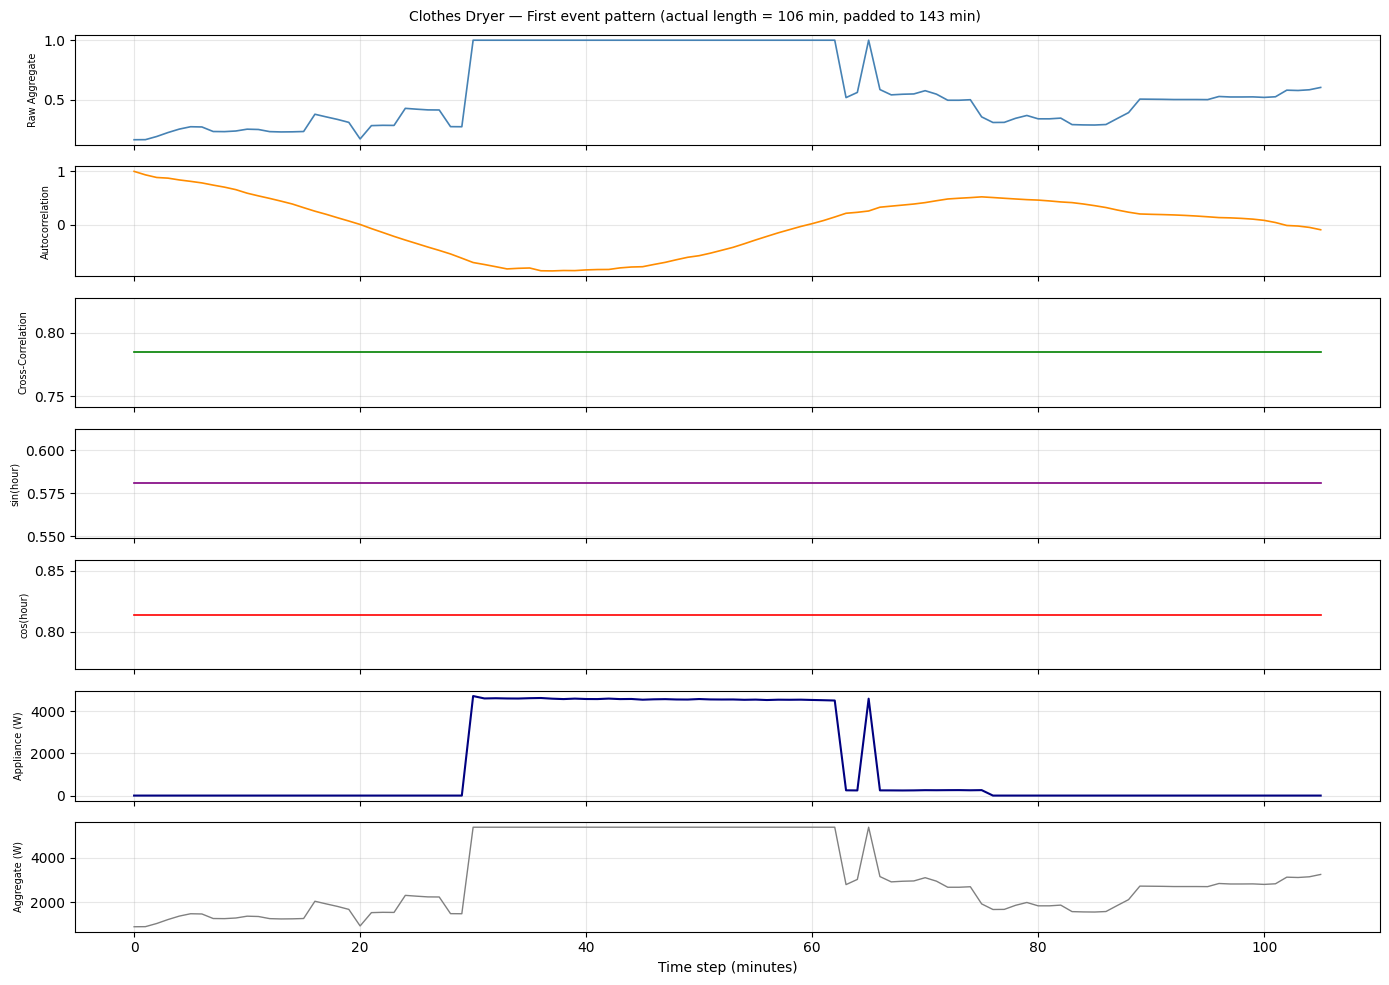

In [ ]:
ch_names  = ['Raw Aggregate', 'Autocorrelation', 'Cross-Correlation',
             'sin(hour)', 'cos(hour)']
ch_colors = ['steelblue', 'darkorange', 'green', 'purple', 'red']

for app, d in datasets.items():
    if len(d['X_train']) == 0:
        continue

    X_ex   = d['X_train'][0]   # (max_len, 7)
    y_ex   = d['y_train'][0]   # (max_len,)
    mask   = d['mask_train'][0] # (max_len,)
    actual_len = int(mask.sum())

    # Convert back to Watts for display
    cap_m  = norm_caps[MAINS_COL]
    cap_a  = norm_caps.get(app, 1.0)

    fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)

    # 5 aggregate channels
    for c, (ax, name, color) in enumerate(
            zip(axes[:5], ch_names, ch_colors)):
        ax.plot(X_ex[:actual_len, c], color=color, linewidth=1.2)
        ax.set_ylabel(name, fontsize=7)
        ax.grid(True, alpha=0.3)

    # Appliance sequence (target)
    axes[5].plot(y_ex[:actual_len] * cap_a,
                 color='navy', linewidth=1.5)
    axes[5].set_ylabel('Appliance (W)', fontsize=7)
    axes[5].grid(True, alpha=0.3)

    # Aggregate in Watts
    axes[6].plot(X_ex[:actual_len, 0] * cap_m,
                 color='gray', linewidth=1.0)
    axes[6].set_ylabel('Aggregate (W)', fontsize=7)
    axes[6].set_xlabel('Time step (minutes)')
    axes[6].grid(True, alpha=0.3)

    fig.suptitle(
        f'{app} — First event pattern '
        f'(actual length = {actual_len} min, padded to {d["max_len"]} min)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    break  # show first appliance only to keep output short

## 14 · Export Datasets

In [112]:
# We save X, y, and mask as separate numpy files per appliance per split.
# CSV would be too large for sequences — numpy is faster and smaller.

for app, d in datasets.items():
    safe = app.replace(' ', '_').replace('/', '-')
    app_dir = os.path.join('nilm_datasets', safe)
    os.makedirs(app_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        X    = d[f'X_{split}']     # (N, max_len, 7)
        y    = d[f'y_{split}']     # (N, max_len)
        mask = d[f'mask_{split}']  # (N, max_len)

        if len(X) == 0:
            print(f'  {app} {split}: empty — skipped')
            continue

        np.save(os.path.join(app_dir, f'X_{split}.npy'),    X)
        np.save(os.path.join(app_dir, f'y_{split}.npy'),    y)
        np.save(os.path.join(app_dir, f'mask_{split}.npy'), mask)

        print(f'  {app:<20} {split:<6}: '
              f'X={X.shape}  y={y.shape}')

# Save max_lens for pipeline notebook
pd.DataFrame([max_lens]).to_csv('nilm_datasets/max_lens.csv', index=False)
print('\nSaved: nilm_datasets/max_lens.csv')
print('Export complete.')

  Clothes Dryer        train : X=(361, 143, 7)  y=(361, 143)
  Clothes Dryer        val   : X=(18, 143, 7)  y=(18, 143)
  Clothes Dryer        test  : X=(78, 143, 7)  y=(78, 143)
  Clothes Washer       train : X=(563, 46, 7)  y=(563, 46)
  Clothes Washer       val   : X=(30, 46, 7)  y=(30, 46)
  Clothes Washer       test  : X=(120, 46, 7)  y=(120, 46)
  Dishwasher           train : X=(496, 107, 7)  y=(496, 107)
  Dishwasher           val   : X=(32, 107, 7)  y=(32, 107)
  Dishwasher           test  : X=(108, 107, 7)  y=(108, 107)
  Kitchen Fridge       train : X=(23348, 373, 7)  y=(23348, 373)
  Kitchen Fridge       val   : X=(1383, 373, 7)  y=(1383, 373)
  Kitchen Fridge       test  : X=(4019, 373, 7)  y=(4019, 373)
  Heat Pump            train : X=(1685, 503, 7)  y=(1685, 503)
  Heat Pump            val   : X=(117, 503, 7)  y=(117, 503)
  Heat Pump            test  : X=(420, 503, 7)  y=(420, 503)

Saved: nilm_datasets/max_lens.csv
Export complete.


In [ ]:
print('fhf')

fhf)
